# Keyboard Tracking

In [1]:
import os
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display

# Blender Export

### Exporting labels

```python
export_coordinates.py
```

### Preview Labels

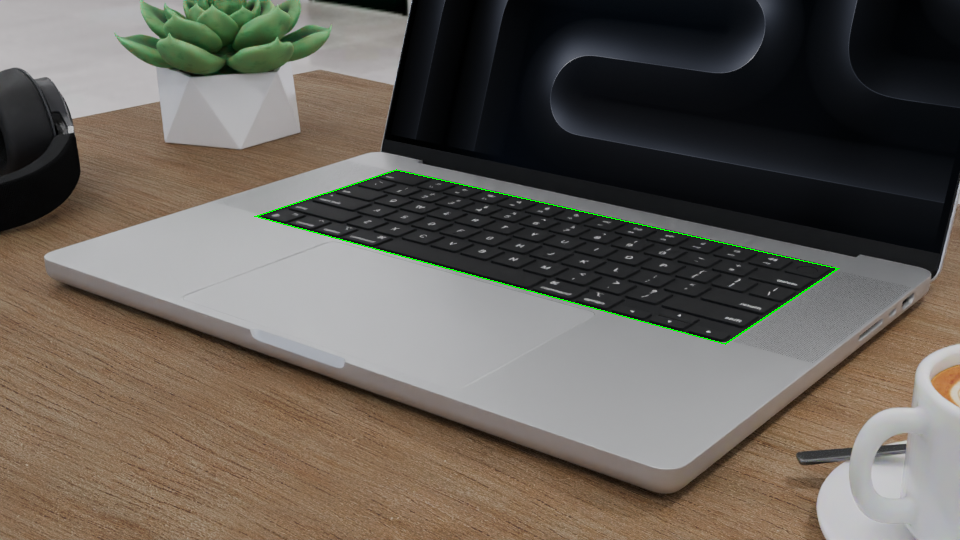

In [48]:
data_dir = os.path.abspath('../data/keyboard_tracking')

scene_name = 'Scene-5'

# Path to your CSV file
CSV_FILE = os.path.join(data_dir, f'labels/{scene_name}.csv')

# Folder where your rendered frames are located
# e.g., "C:/path/to/my_rendered_images"
IMAGE_FOLDER = os.path.join(data_dir, f'raw/{scene_name}')

def preview_blender_export(csv_file, image_folder, frame_number=0):
    """
    Reads the 2D coordinates from a CSV file, opens the corresponding
    rendered images, draws markers for each point, and saves new images
    to output_folder.
    """

    # Use DictReader so we can access columns by name
    keypoints_df = pd.read_csv(csv_file)

    # get row where Frame is equal to frame_number
    row = keypoints_df[keypoints_df['Frame'] == frame_number].iloc[0]
    
    # Build the image file name (e.g., frame_0001.png)
    # Adjust to match your own naming convention:
    image_filename = f"{scene_name}-{frame_number:04d}.png"
    image_path = os.path.join(image_folder, image_filename)

    # Try to open the image
    if not os.path.isfile(image_path):
        print(f"Warning: Image not found at {image_path}")
        return

    # Load image using Pillow
    with Image.open(image_path) as im:
        # get image size
        width, height = im.size

        draw = ImageDraw.Draw(im)

        draw.polygon([(int(row['keyboard-lt_x']), int(row['keyboard-lt_y'])),
                      (int(row['keyboard-rt_x']), int(row['keyboard-rt_y'])),
                      (int(row['keyboard-rb_x']), int(row['keyboard-rb_y'])),
                      (int(row['keyboard-lb_x']), int(row['keyboard-lb_y']))],
                      outline=(0, 255, 0), width=2)

        # List all empties and their columns
        empties = ["keyboard-lt", "keyboard-lb", "keyboard-rt", "keyboard-rb"]

        # Show the image with the drawn points
        display(im)

preview_blender_export(CSV_FILE, IMAGE_FOLDER, frame_number=0)

In [25]:
import torch

USE_CPU = True

device = torch.device(
    "cuda:0" if torch.cuda.is_available() and not USE_CPU else
    "mps" if torch.backends.mps.is_available() and not USE_CPU else
    "cpu"
)
print('You are using the following device: ', device)

You are using the following device:  cpu


# Dataset

In [49]:
import sys
sys.path.append(os.path.abspath('..'))

from models.keyboard_tracking.dataset import KeyboardTrackingDataset

data_dir = os.path.abspath('../data/keyboard_tracking')
labels_dir = os.path.join(data_dir, 'labels')
images_dir = os.path.join(data_dir, 'raw')

dataset = KeyboardTrackingDataset(labels_dir, images_dir, device=device)

train_size = int(len(dataset) * 0.7)
val_size = int(len(dataset) * 0.2)
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1312
Validation dataset size: 375
Test dataset size: 188


### Preview Dataset

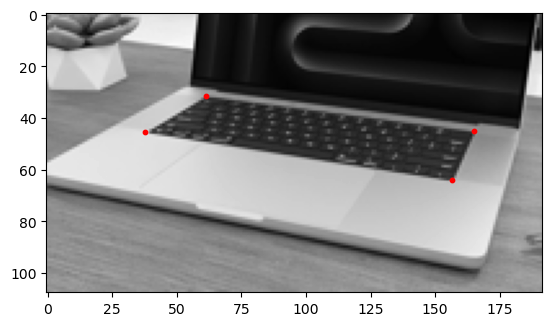

In [58]:
import matplotlib.pyplot as plt

def preview_keypoints(dataset, predicted_keypoints=None, idx=0):
    image, keypoints = dataset[idx]

    image = image.cpu().numpy().transpose(1, 2, 0)
    keypoints = keypoints.cpu().numpy()

    fig, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    keypoints = keypoints.reshape(-1, 2) - 1
    ax.scatter(keypoints[:, 0], keypoints[:, 1], s=10, c='r', marker='o')
    if predicted_keypoints is not None:
        predicted_keypoints = predicted_keypoints.cpu().numpy()
        predicted_keypoints = predicted_keypoints.reshape(-1, 2) - 1
        ax.scatter(predicted_keypoints[:, 0], predicted_keypoints[:, 1], s=10, c='g', marker='o')
    plt.show()

preview_keypoints(train_dataset, idx=5)

# Training

In [61]:
hparams = {
    'device': device,
    'num_classes': 8,
    'num_workers': 8,
    'batch_size': 64,
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'max_epochs': 40,
}

In [60]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import random

from models.keyboard_tracking.model import KeyboardTrackingModel

# Progress bar
def create_tqdm_bar(iterable, desc):
    return tqdm(enumerate(iterable),total=len(iterable), ncols=150, desc=desc)

# Random run id
run_id = f'{random.randint(0, 100000):05d}'

# Tensorboard
log_dir = os.path.abspath('../logs/keyboard_tracking')
num_of_runs = len(os.listdir(log_dir)) if os.path.exists(log_dir) else 0
path = os.path.join(log_dir, f'run_{(num_of_runs + 1):02d}_{run_id}')
tb_logger = SummaryWriter(path)

batch_size = hparams['batch_size']
num_workers = hparams['num_workers']
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, persistent_workers=True)

# Model + Optimizer
model_name = 'default'

model_path = os.path.abspath('../saved_models/keyboard_tracking')
os.makedirs(model_path, exist_ok=True)
model_path = os.path.join(model_path, sorted(os.listdir(model_path))[-1])
print(f"Loading model from {model_path}")

model = KeyboardTrackingModel(hparams)
model.load_state_dict(torch.load(model_path))
model.to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=hparams['learning_rate'], weight_decay=hparams['weight_decay'])
val_loss = 0
max_epochs = hparams['max_epochs']

for epoch in range(max_epochs):
    # Training loop
    model.train()
    train_loss = 0
    train_loop = create_tqdm_bar(train_loader, 'Training')
    for train_iteration, batch in train_loop:
        images, keypoints = batch

        optimizer.zero_grad()
        predicted_keypoints = model(images)
        loss = criterion(predicted_keypoints, keypoints)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(curr_train_loss = "{:.8f}".format(train_loss / (train_iteration + 1)), val_loss = "{:.8f}".format(val_loss))

        tb_logger.add_scalar(f'keyboard_tracker_{model_name}/train_loss', train_loss, epoch * len(train_loader) + train_iteration)
    
    train_loss /= len(train_loader)

    # Validation loop
    model.eval()
    val_loss = 0
    val_loop = create_tqdm_bar(val_loader, 'Validation')
    with torch.no_grad():
        for val_iteration, val_batch in val_loop:
            image, keypoints = val_batch
            predicted_keypoints = model(image)
            loss = criterion(
                torch.squeeze(keypoints), torch.squeeze(predicted_keypoints)
            ).item()
            val_loss += loss

            val_loop.set_postfix(curr_train_loss = "{:.8f}".format(train_loss), val_loss = "{:.8f}".format(val_loss / (val_iteration + 1)))

            tb_logger.add_scalar(f'keyboard_tracker_{model_name}/val_loss', val_loss, epoch * len(val_loader) + val_iteration)

    # This value is used for the progress bar of the training loop.
    val_loss /= len(val_loader)

    print(f"Epoch {epoch + 1}/{max_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Loading model from /Users/lucasaschenbach/Projects/Hackathons/proof-of-gameplay/model/saved_models/keyboard_tracking/keyboard_tracking_09_68234.pth


/var/folders/88/lm1ppn855fbcj6m9qzlkrv_h0000gn/T/ipykernel_14434/2571739918.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path)

Epoch 1/40 - Train Loss: 617.9769 - Val Loss: 423.1325



Validation: 100%|██████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.41it/s, curr_train_loss=354.49236915, val_loss=319.51757304]

Epoch 2/40 - Train Loss: 354.4924 - Val Loss: 319.5176


...

Epoch 38/40 - Train Loss: 8.2919 - Val Loss: 21.1705



Validation: 100%|█████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.46it/s, curr_train_loss=9.22067456, val_loss=21.75880241]

Epoch 39/40 - Train Loss: 9.2207 - Val Loss: 21.7588



Validation: 100%|█████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.11it/s, curr_train_loss=8.91578329, val_loss=17.65502548]

Epoch 40/40 - Train Loss: 8.9158 - Val Loss: 17.6550


### Save Model

In [62]:
# Save the model
model_path = os.path.abspath('../saved_models/keyboard_tracking')
os.makedirs(model_path, exist_ok=True)
num_of_runs = len(os.listdir(model_path)) if os.path.exists(model_path) else 0
model_name = f'keyboard_tracking_{(num_of_runs + 1):02d}_{run_id}.pth'
model_path = os.path.join(model_path, model_name)

torch.save(model.state_dict(), model_path)
print(f"Model saved at {model_path}")

Model saved at /Users/lucasaschenbach/Projects/Hackathons/proof-of-gameplay/model/saved_models/keyboard_tracking/keyboard_tracking_09_49924.pth


# Evaluation

In [63]:
# evaluate model on test set
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=num_workers)

model.eval()
test_loss = 0
test_loop = create_tqdm_bar(test_loader, 'Testing')
with torch.no_grad():
    for test_iteration, test_batch in test_loop:
        image, keypoints = test_batch
        predicted_keypoints = model(image)
        loss = criterion(
            torch.squeeze(keypoints), torch.squeeze(predicted_keypoints)
        ).item()
        test_loss += loss
        test_loop.set_postfix(test_loss = "{:.8f}".format(test_loss / (test_iteration + 1)))

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}")

Testing: 100%|███████████████████████████████████████████████████████████████████████████████| 188/188 [00:03<00:00, 49.99it/s, test_loss=16.94428042]

Test Loss: 16.9443


### Preview Evaluation

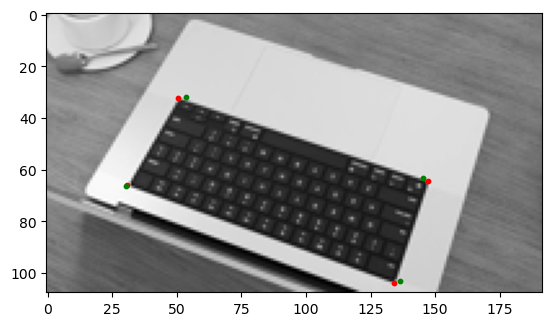

In [86]:
idx = 0
image, keypoints = test_dataset[idx]

model.eval()
with torch.no_grad():
    predicted_keypoints = model(image.unsqueeze(0))
    preview_keypoints(test_dataset, predicted_keypoints, idx)